## GPU Computing - Introduction

### ****Milestone 1:** Mandelbrot Float32 Kernel (35 min)**

****Follow** `mandelbrot_tutorial.md` (attached on Moodle). Type the code yourself — that is the goal. The tutorial walks through every step. If you get stuck, peek at `mandelbrot_opencl.py` (don’t open until your own version runs).**

#### ****Step 0** — Prerequisites**

- **PyOpenCL installed and working (you verified this at the end of L09):**

In [1]:
!python -c "import pyopencl as cl; [print(p.name, [d.name for d in p.get_devices()]) for p in cl.get_platforms()]"

AMD Accelerated Parallel Processing ['gfx1035']
Intel(R) OpenCL ['AMD Ryzen 7 PRO 6850U with Radeon Graphics     ']


**should list your GPU — not just Portable Computing Language ['cpu']**

It does list my GPU **✓**

- **Your Numba Mandelbrot from MP1 in front of you. You will port its inner loop to OpenCL C.**

Noted!

**Create a new file `mandelbrot_gpu.py` in your MP3 repo and follow along.**

In [2]:
!touch mandelbrot_gpu.py

#### **Step 1 — The host/device mental model**

**A PyOpenCL program has two halves:**

| Half   | Lives in    | Written in | Role                                              |
| ------ | ----------- | ---------- | ------------------------------------------------- |
| Host   | Your Python | Python     | Allocate buffers, launch kernels, collect results |
| Device | The GPU     | OpenCL C   | The kernel — the parallel loop body               |

**Three objects connect them:**

- **Context (`cl.Context`) — "who am I talking to?" — one or more devices.**

- **Command queue (`cl.CommandQueue`) — an ordered pipe for work sent to a device.**

- **Buffer (`cl.Buffer`) — a region of device memory. Inputs and outputs live here.**

**The pattern is always: *create context + queue → allocate buffers → compile kernel → enqueue kernel → copy results back*.**

I shall note all of this! In step 2, we do this "plumbing".

#### ****Step 2 — Skeleton:** the shortest possible program that launches a kernel**

**Type this in. It does nothing useful yet, but it verifies the plumbing.**

In [3]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void hello(__global int *out) {
    int i = get_global_id(0);
    out[i] = i * i;
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N = 8
out = np.zeros(N, dtype=np.int32)
out_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, out.nbytes)

prog.hello(queue, (N,), None, out_dev)
cl.enqueue_copy(queue, out, out_dev)
queue.finish()

print(out)     # → [ 0  1  4  9 16 25 36 49]


**Run it. If this prints the squares, your whole toolchain works. If it fails, fix that now — every later step builds on it.**

In [4]:
%run mandelbrot_gpu.py

/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/__init__.py:578: UserWarning: PyOpenCL compiler caching failed with an exception:
[begin exception]
Traceback (most recent call last):
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 514, in create_built_program_from_source_cached
    _create_built_program_from_source_cached(
  File "/opt/conda/envs/nsc/lib/python3.11/site-packages/pyopencl/cache.py", line 424, in _create_built_program_from_source_cached
    src = src + b"\n\n__constant int pyopencl_defeat_cache_%s = 0;" % (
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: %b requires a bytes-like object, or an object that implements __bytes__, not 'str'
[end exception]
  lambda: create_built_program_from_source_cached(


[ 0  1  4  9 16 25 36 49]


It works! (ignore warnings)

#### ****Step 3** — Kernel signature for Mandelbrot**

**Decide what the kernel needs to know. For each pixel you need:**

- **Pixel coordinates (row, col) — the kernel gets these from `get_global_id`**
- **The view window (`x_min, x_max, y_min, y_max`)**
- **Image dimension `N`**
- **`max_iter`**
- **Somewhere to write the result**

**So the signature is:**

```c
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    // body to fill in
}
```

**Add this to your Python file as the new `KERNEL_SRC`. Leave the body empty for now. Note: one work-item = one pixel. We'll launch with an NDRange of `(N, N)`, so `get_global_id(0)` gives the column and `get_global_id(1)` the row.**

In [5]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    // body to fill in
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N = 8
out = np.zeros(N, dtype=np.int32)
out_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, out.nbytes)

prog.hello(queue, (N,), None, out_dev)
cl.enqueue_copy(queue, out, out_dev)
queue.finish()

print(out)     # → [ 0  1  4  9 16 25 36 49]


I have added it. I have noted the text.

#### ****Step 4** — Map pixel → complex number**

**At the top of the body:**

```c
int col = get_global_id(0);
int row = get_global_id(1);
if (col >= N || row >= N) return;   // guard against over-launch

float c_real = x_min + col * (x_max - x_min) / (float)N;
float c_imag = y_min + row * (y_max - y_min) / (float)N;
```

**Two things to notice:**

- ****Explicit cast** `(float)N`. Integer division is a classic C bug. If you forget the cast, you get 0.0 for most pixels. (See Appendix A.)**
- ****No NumPy.** The kernel is scalar code. One work-item = one pixel = one Python loop iteration you did in MP1.**


I have noticed this!

#### ****Step 5** — Translate the escape-time loop**

**Your Numba inner loop probably looks like this:**

```python
zr, zi = 0.0, 0.0
count = 0
while count < max_iter and zr*zr + zi*zi <= 4.0:
    zr, zi = zr*zr - zi*zi + c_real, 2.0 * zr * zi + c_imag
    count += 1
```

**The OpenCL C version is line-for-line analogous, except Python's simultaneous assignment does not exist — you need a temp:**

```c
float zr = 0.0f, zi = 0.0f;
int count = 0;
while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
    float tmp = zr*zr - zi*zi + c_real;
    zi = 2.0f * zr * zi + c_imag;
    zr = tmp;
    count++;
}
result[row * N + col] = count;
```

The `f` suffix (`0.0f, 4.0f, 2.0f`) keeps literals as `float`. Without it, `4.0` is a `double`, which silently promotes the whole expression and slows the kernel on GPUs where double is expensive.

Your kernel is now complete. Copy its source into the `KERNEL_SRC` triple-quoted string.

Yes. We do indeed need a tmp variable. I shall copy it.

In [6]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;   // guard against over-launch

    float c_real = x_min + col * (x_max - x_min) / (float)N;
    float c_imag = y_min + row * (y_max - y_min) / (float)N;

    float zr = 0.0f, zi = 0.0f;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
        float tmp = zr*zr - zi*zi + c_real;
        zi = 2.0f * zr * zi + c_imag;
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N = 8
out = np.zeros(N, dtype=np.int32)
out_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, out.nbytes)

prog.hello

#### ****Step 6** — Host code: buffers, launch, copy back**

**Below the `ctx/queue/prog` setup, add:**

```c
N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image = np.zeros((N, N), dtype=np.int32)
image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

prog.mandelbrot(
    queue, (N, N), None,      # global size (N, N); let OpenCL pick local
    image_dev,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(N), np.int32(MAX_ITER),
)

cl.enqueue_copy(queue, image, image_dev)
queue.finish()
```

**Two details that matter:**

- ****Every scalar must be wrapped as `np.float32(...)` or `np.int32(...)`.** PyOpenCL won't convert Python scalars for you — a plain `1024` vs `np.int32(1024)` mismatches the kernel signature and fails silently with garbled output.**
- **`queue.finish()` is the barrier. Without it, the copy may not have completed when Python reads `image`.**

I have added it. I have noted the text above!

In [7]:
%pycat mandelbrot_gpu.py

import pyopencl as cl
import numpy as np

KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    if (col >= N || row >= N) return;   // guard against over-launch

    float c_real = x_min + col * (x_max - x_min) / (float)N;
    float c_imag = y_min + row * (y_max - y_min) / (float)N;

    float zr = 0.0f, zi = 0.0f;
    int count = 0;
    while (count < max_iter && zr*zr + zi*zi <= 4.0f) {
        float tmp = zr*zr - zi*zi + c_real;
        zi = 2.0f * zr * zi + c_imag;
        zr = tmp;
        count++;
    }
    result[row * N + col] = count;
}
"""

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image = np.zeros((N, N), dtype=np.in

#### ****Step 7** — Time it and save the image**

```python
import time, matplotlib.pyplot as plt

# --- Warm up (first launch triggers a kernel compile) ---
prog.mandelbrot(queue, (64, 64), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(64), np.int32(MAX_ITER))
queue.finish()

# --- Time the real run ---
t0 = time.perf_counter()
prog.mandelbrot(queue, (N, N), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(N), np.int32(MAX_ITER))
queue.finish()
elapsed = time.perf_counter() - t0

cl.enqueue_copy(queue, image, image_dev)
queue.finish()

print(f"GPU {N}x{N}: {elapsed*1e3:.1f} ms")
plt.imshow(image, cmap='hot', origin='lower'); plt.axis('off')
plt.savefig("mandelbrot_gpu.png", dpi=150, bbox_inches='tight')
```

****Done?** Record the runtime in your performance notebook and commit. That's MP3 M1.**

/tmp/ipykernel_35849/826446621.py:27: RepeatedKernelRetrieval: Kernel 'mandelbrot' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  prog.mandelbrot(queue, (N, N), None, image_dev,


GPU 1024x1024: 1.8 ms


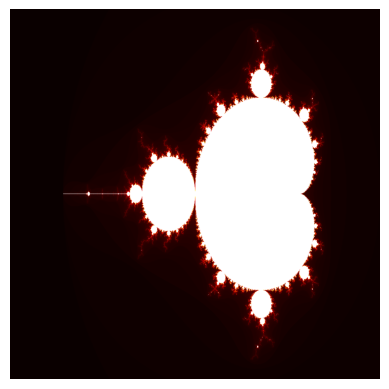

In [8]:
import time
import matplotlib.pyplot as plt
import pyopencl as cl
import numpy as np
from mandelbrot_gpu import KERNEL_SRC

ctx   = cl.create_some_context(interactive=False)
queue = cl.CommandQueue(ctx)
prog  = cl.Program(ctx, KERNEL_SRC).build()

N, MAX_ITER = 1024, 200
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.25, 1.25

image = np.zeros((N, N), dtype=np.int32)
image_dev = cl.Buffer(ctx, cl.mem_flags.WRITE_ONLY, image.nbytes)

# --- Warm up (first launch triggers a kernel compile) ---
prog.mandelbrot(queue, (64, 64), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(64), np.int32(MAX_ITER))
queue.finish()

# --- Time the real run ---
t0 = time.perf_counter()
prog.mandelbrot(queue, (N, N), None, image_dev,
                np.float32(X_MIN), np.float32(X_MAX),
                np.float32(Y_MIN), np.float32(Y_MAX),
                np.int32(N), np.int32(MAX_ITER))
queue.finish()
elapsed = time.perf_counter() - t0

cl.enqueue_copy(queue, image, image_dev)
queue.finish()

print(f"GPU {N}x{N}: {elapsed*1e3:.1f} ms")
plt.imshow(image, cmap='hot', origin='lower'); plt.axis('off')
plt.savefig("mandelbrot_gpu.png", dpi=150, bbox_inches='tight')

I have now completed the `mandelbrot_tutorial.md`.

```python
# From slide 9

# Kernel signature -- fill in the body following the tutorial
KERNEL_SRC = """
__kernel void mandelbrot(
    __global int *result,
    const float x_min, const float x_max,
    const float y_min, const float y_max,
    const int N, const int max_iter)
{
    int col = get_global_id(0);
    int row = get_global_id(1);
    // ... your escape-time loop here ...
}"""

# Host launch -- note np.float32/np.int32 wrapping for every scalar
prog.mandelbrot(
    queue, (N, N), None, image_dev,
    np.float32(X_MIN), np.float32(X_MAX),
    np.float32(Y_MIN), np.float32(Y_MAX),
    np.int32(N), np.int32(MAX_ITER),
)
queue.finish()
```

- **The kernel is a direct translation of your Numba escape-time loop into OpenCL C**

Noted! Yes it is a direct translation.

- **Each work-item computes its own *c* from its pixel coordinates — no input array needed**

Indeed yes. This was fixed in OpenCL using the `tmp` variable.

- **Launch with 2D global size `(N, N)`; wrap every scalar as `np.float32(...)/np.int32(...)`**

Done. Please see the code above from step 7.

- **Visualise with `plt.imshow` and save the image**

Done. Please see the outputted image above from step 7.

****After it produces a correct image, time it:****

- **Add a warm-up call first (first launch triggers kernel JIT compile)**

Done in step 7 above.

- **Time with `time.perf_counter()`; call `queue.finish()` before stopping the clock**

Noted! Done! Please see the code above from step 7.

****Done?** Record GPU f32 runtime in performance notebook (MP3) → commit**

```sh
┌──(mikkel@pella)-[~/Sync/AAU/Semester 8/github/nsc-mikkel]
└─$ git log -n 1
commit aa3a638a6259121b11a00b227528f3c6f9868ddf (HEAD -> main)
Author: mikkel-coder <mikkel.ks.sorensen@gmail.com>
Date:   Wed Apr 22 11:06:13 2026 +0000

    l10: milestone 1 done
```

### ****Milestone 2:** Float32 vs Float64 (20 min)**

****Task:** Add a float64 version and compare speed and image quality.**

In [ ]:
# From slide 11

# 1. Check fp64 support
dev = ctx.devices[0]
if 'cl_khr_fp64' not in dev.extensions:
    print("No native fp64 -- Apple Silicon: emulated, expect large slowdown")

# 2. Add this pragma at the top of your f64 kernel string
#pragma OPENCL EXTENSION cl_khr_fp64 : enable

# 3. Three changes inside the kernel:
#    float  -> double
#    0.0f, 4.0f -> 0.0, 4.0     (drop the f suffix)
#     (float)N  -> (double)N

# 4. Wrap scalars as np.float64(...) in the host launch call

1. **Check that your device supports fp64 (see code example)**

2. **Copy your M1 kernel; rename to `mandelbrot_f64`; change: `float` → `double`, literal suffixes `0.0f/4.0f → 0.0/4.0`; add the pragma line at the top**

3. **Time both at $N=1024$ and $N=2048$ — what is the f32/f64 speed ratio?**

- **Is the measured speed ratio consistent with your Roofline prediction?**

- **Apple Silicon (M-series): fp64 is emulated in software — expect a very large slowdown**

****Done?** Record f32 and f64 runtimes in performance notebook (MP3) → commit**

### ****Milestone 3:** Benchmark GPU**

****Task:** Time your GPU kernels at the same grid sizes you used in MP1 and MP2. Reuse the CPU runtimes already in your performance notebook — no need to re-run them.**

In [ ]:
# From slide 13

import statistics, time, matplotlib.pyplot as plt
def timed(fn, runs=3):
    ts = []
    for _ in range(runs):
        t0 = time.perf_counter()
        fn(); queue.finish()     # queue.finish() waits for GPU
        ts.append(time.perf_counter() - t0)
    return statistics.median(ts)

N = 1024                        # match your MP1/MP2 benchmark N
results = {
    "GPU f32": timed(lambda: run_mandelbrot_f32(N)),
    "GPU f64": timed(lambda: run_mandelbrot_f64(N)),
    # Paste your MP1/MP2 runtimes here:
    # "Naive": ..., "NumPy": ..., "Numba": ...,
}
names, times = zip(*results.items())
plt.bar(names, times, log=True)
plt.ylabel("seconds (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("benchmark_mp3.png", dpi=150)

1. **Time `mandelbrot_gpu_f32` and `mandelbrot_gpu_f64` at your benchmark *N* values**

2. **Combine GPU runtimes with your recorded MP1/MP2 numbers**

3. **Plot as a bar chart with a log-scale y -axis — this is the MP3 performance comparison figure**

- **Include: naive Python, NumPy, Numba f32/f64, multiprocessing, Dask local, Dask cluster, GPU f32, GPU f64**

- **Where does GPU sit relative to Numba? To naive Python? (Recall the L01 starting point.)**

****Done?** Combined benchmark chart in performance notebook (MP3) → commit**